In [14]:
import sys
from pathlib import Path
from typing import Literal

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Ensure project root is in path
PROJECT_ROOT = Path(__file__).resolve().parent.parent if "__file__" in globals() else Path(".").resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [15]:
RESULTS_DIR = PROJECT_ROOT / "results"

COLOR_ORIGINAL  = "#5B9BD5"
COLOR_TARGET    = "#F5C431"
COLOR_SYNTHETIC = "#E06C75"

MARKER_ORIGINAL  = "x"
MARKER_TARGET    = "o"
MARKER_SYNTHETIC = "o"

POINT_SIZE = 18

def get_gmcm_encoding_size(percentile_size: float = 0.1, num_features: int = 13) -> int:
    """Returns the number of ``emb_*`` columns that belong to the ``_encodings`` block of a :class:`GMCMEncoderDecoder`.

    Args:
        percentile_size: Percentile step used when building the encoder
            (default ``0.1`` → quantile grid 0, 0.1, …, 1.0 = 11 points).
        num_features:    Number of encoded features (default ``13``, i.e. the
            14-column stat vector after the ``edges`` column is dropped).
    Returns:
        Integer size of the ``_encodings`` block in the flat embedding.
    """
    q = np.arange(0, 1 + percentile_size / 2, percentile_size)
    q[q > 1.0] = 1.0
    if q[-1] < 1.0:
        q = np.append(q, 1.0)
    return int(len(q)) * num_features


def load_flexibility_results(results_dir: Path | str | None = None) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Loads the three CSV files produced by evaluate_flexibility.py."""
    rdir = Path(results_dir) if results_dir is not None else RESULTS_DIR

    paths = {
        "original":  rdir / "original_datasets_mean_stats.csv",
        "target":    rdir / "target_datasets_mean_stats.csv",
        "synthetic": rdir / "synthetic_datasets_mean_stats.csv",
    }

    missing = [k for k, p in paths.items() if not p.exists()]
    if missing:
        raise FileNotFoundError(f"The following result CSV files were not found in {rdir}: {missing}")

    frames = {}
    for key, path in paths.items():
        df = pd.read_csv(path)
        df["source"] = key
        frames[key] = df

    return frames["original"], frames["synthetic"], frames["target"]


def load_combined_results(results_dir: Path | str | None = None) -> pd.DataFrame:
    """Convenience wrapper: loads and concatenates all three result DataFrames."""
    df_orig, df_synth, df_tgt = load_flexibility_results(results_dir)
    return pd.concat([df_orig, df_synth, df_tgt], ignore_index=True)

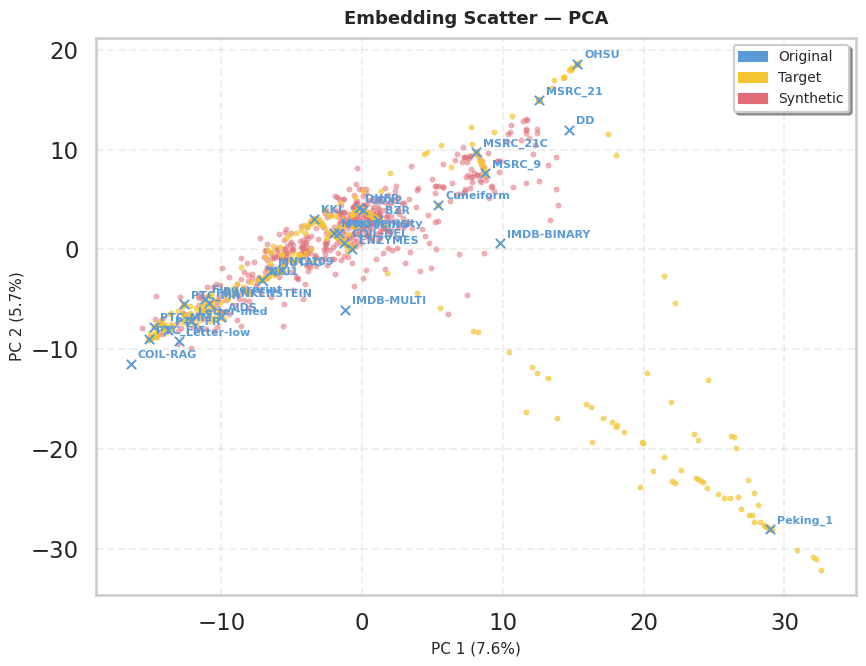

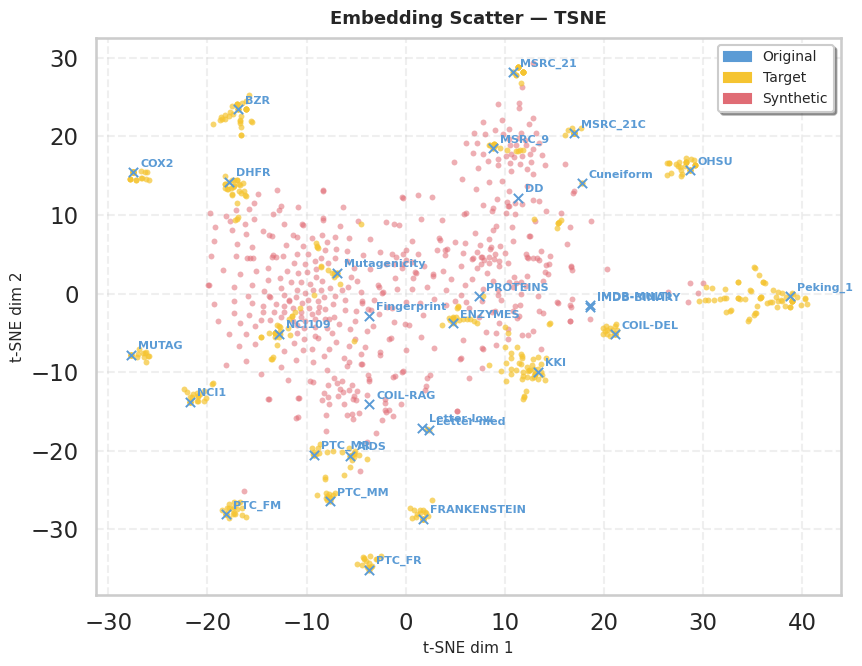

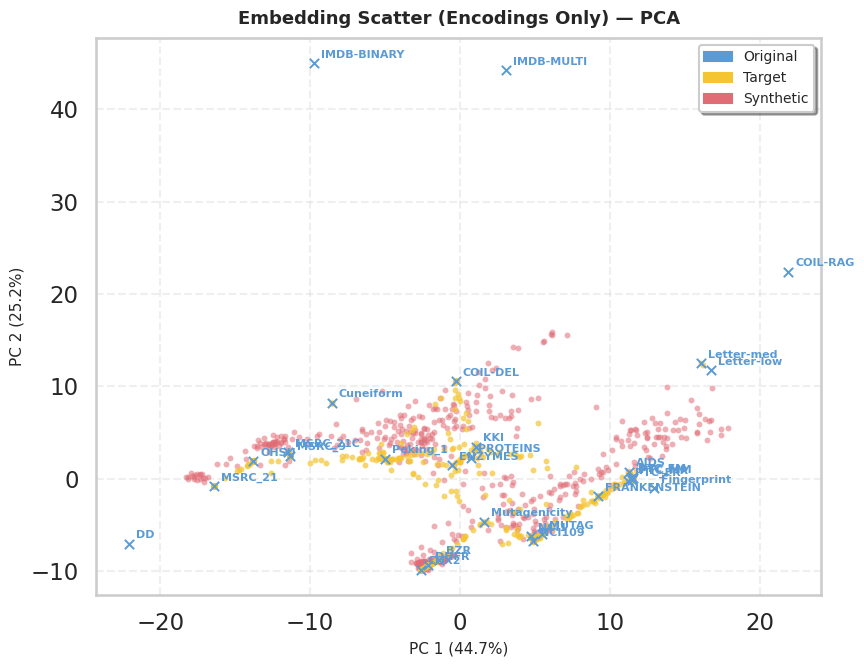

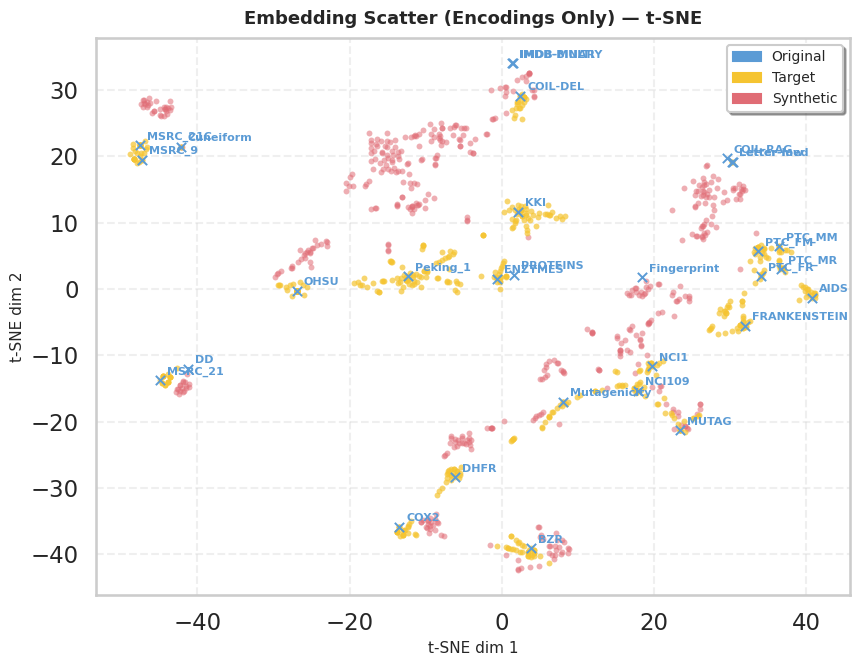

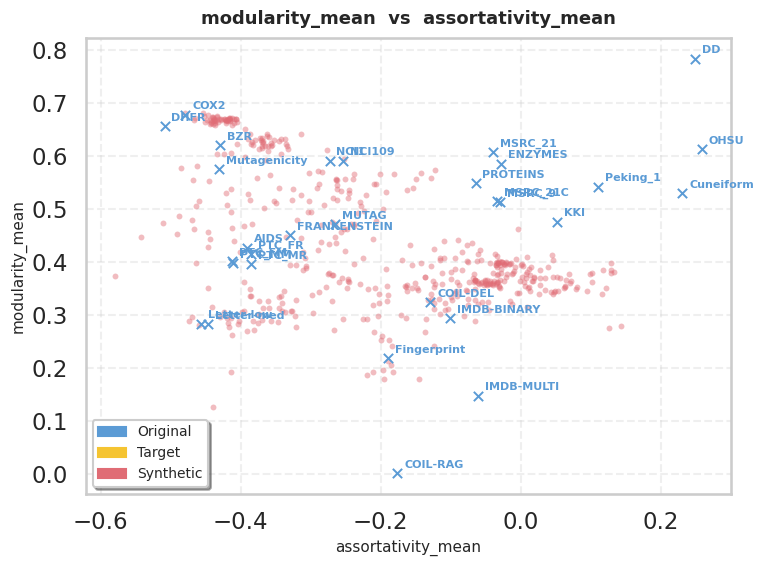

[plot_stat_scatter] Dropped 500 rows with NaN in selected columns.


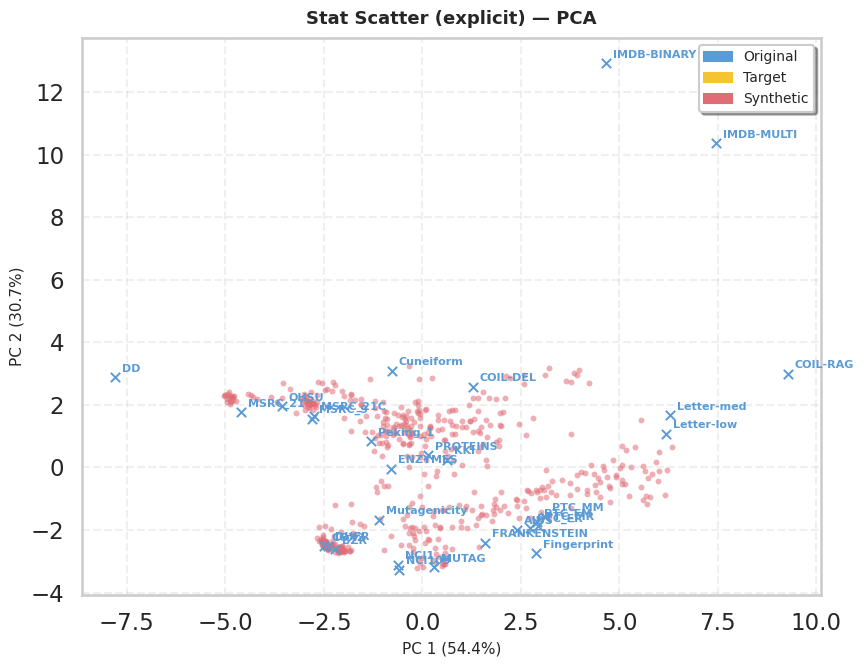

[plot_stat_scatter] Dropped 500 rows with NaN in selected columns.


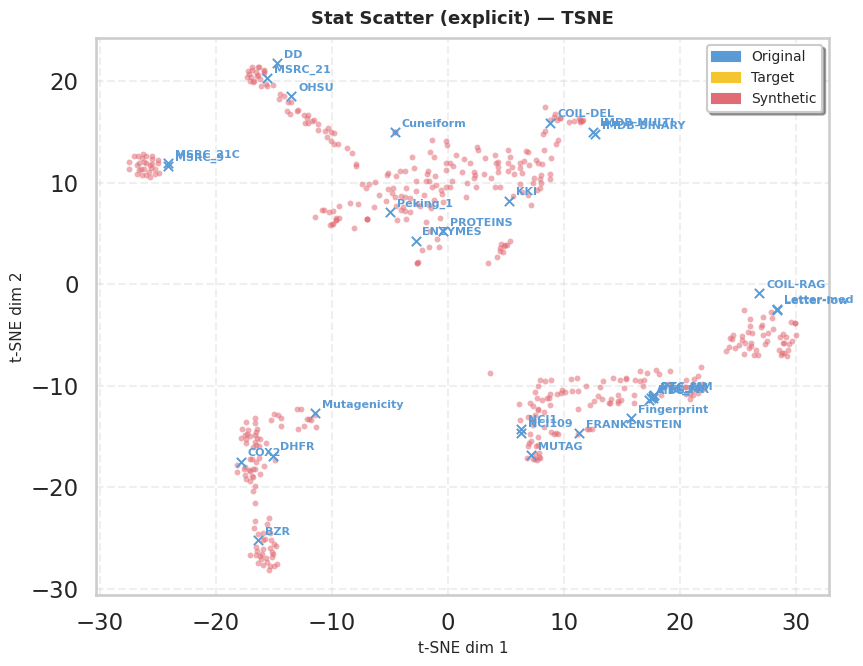

[plot_stat_scatter] Dropped 500 rows with NaN in selected columns.


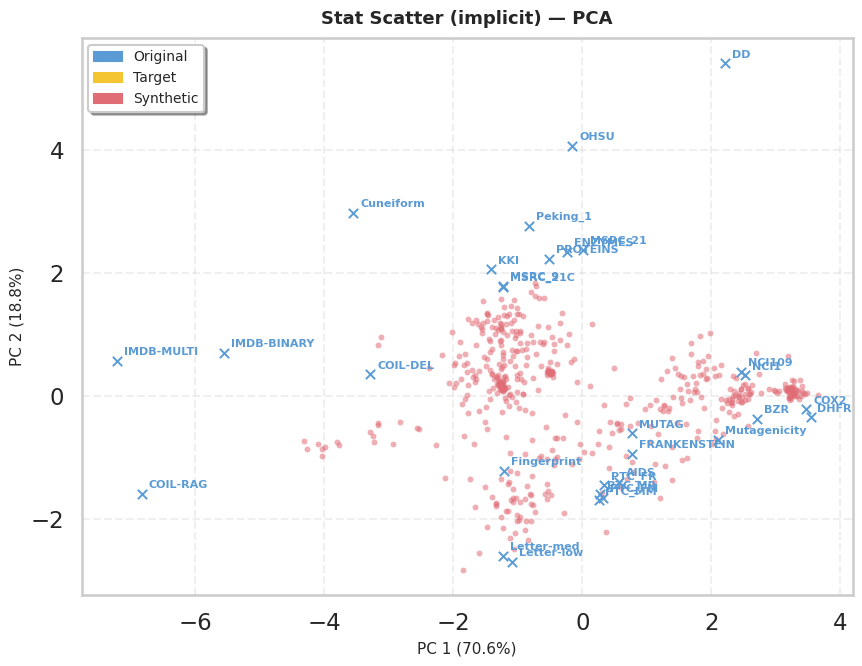

[plot_stat_scatter] Dropped 500 rows with NaN in selected columns.


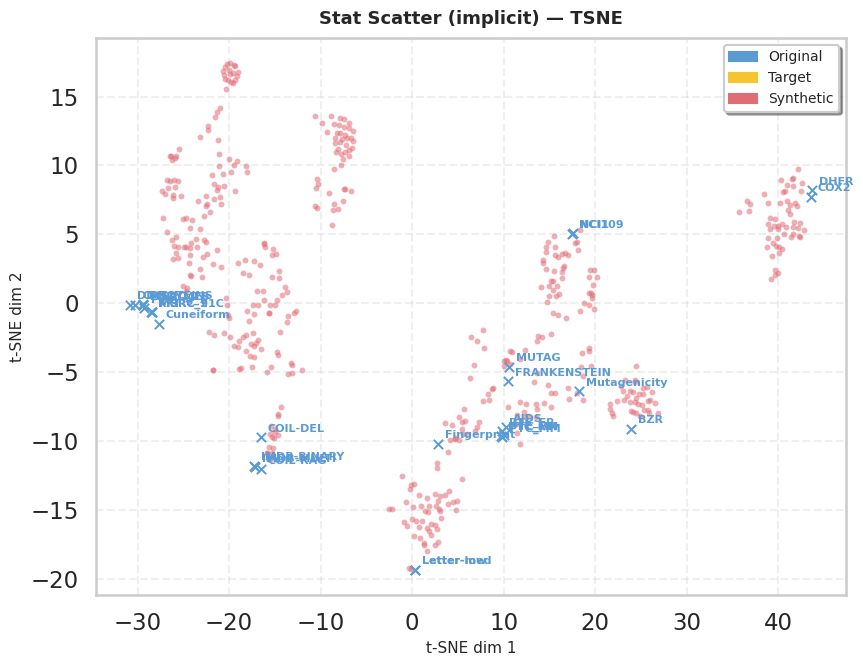

[plot_stat_scatter] Dropped 500 rows with NaN in selected columns.


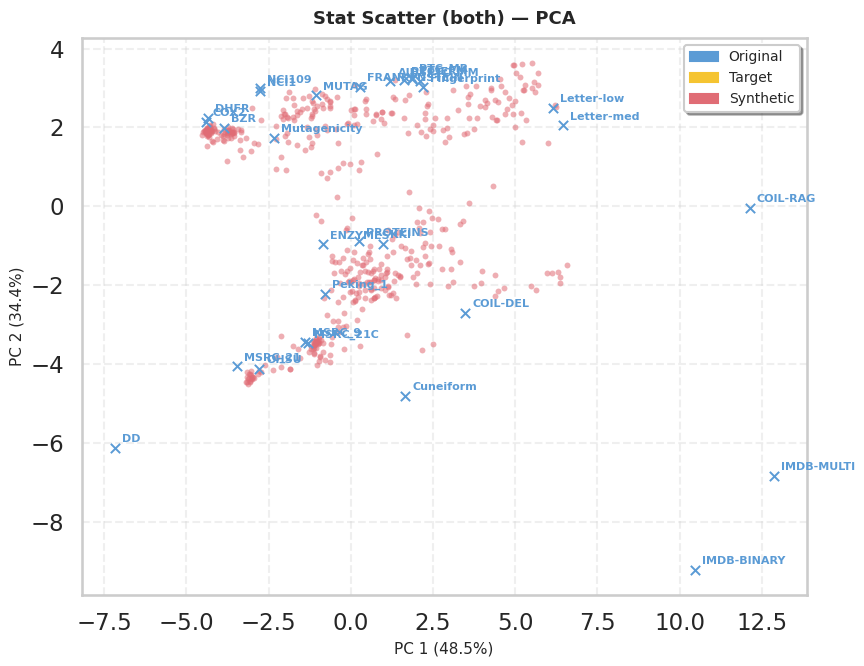

[plot_stat_scatter] Dropped 500 rows with NaN in selected columns.


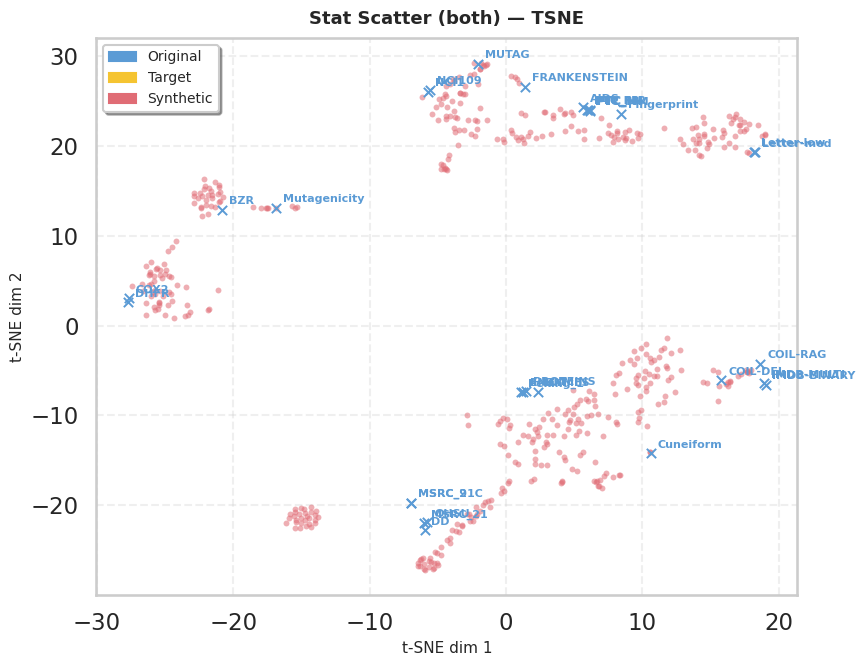

In [ ]:
def plot_embedding_scatter(
    df_original:  pd.DataFrame,
    df_synthetic: pd.DataFrame,
    df_target:    pd.DataFrame,
    method: Literal["pca", "tsne"] = "pca",
    n_encoding_cols: int | None = None,
    percentile_range: tuple[float, float] | None = None,
    perplexity: float = 30.0,
    random_state: int = 42,
    ax: plt.Axes | None = None,
    title: str | None = None,
) -> plt.Axes:
    """Plots a 2-D scatter of the dataset embeddings (``emb_*`` columns).

    Args:
        df_original:  DataFrame of original datasets (one row per dataset).
        df_synthetic: DataFrame of synthetic datasets.
        df_target:    DataFrame of target datasets.
        method:       Dimensionality-reduction method — ``"pca"`` (default) or ``"tsne"``.
        n_encoding_cols: If given, only the **first** ``n_encoding_cols``
            ``emb_*`` columns are used.
        percentile_range: If given, a ``(lo, hi)`` tuple (e.g. ``(5.0, 95.0)``)
            that selects only the embedding dimensions whose variance across all
            three frames falls within that percentile range of variances.  Applied
            **after** ``n_encoding_cols`` slicing.  ``None`` (default) keeps all
            remaining dimensions.
        perplexity:   t-SNE perplexity (ignored when ``method="pca"``).
        random_state: Random seed for reproducibility.
        ax:           Existing Axes to draw into.  A new figure is created when ``None`` (default).
        title:        Plot title override.  Auto-generated when ``None``.
    Returns:
        The matplotlib Axes containing the scatter plot.
    """
    # --- collect emb_* columns ------------------------------------------------
    emb_cols = sorted(
        [c for c in df_original.columns if c.startswith("emb_")],
        key=lambda c: int(c.split("_")[1]),
    )
    if not emb_cols:
        raise ValueError("No 'emb_*' columns found in df_original.")

    # --- optional truncation to the _encodings block --------------------------
    if n_encoding_cols is not None:
        if n_encoding_cols < 2:
            raise ValueError(f"n_encoding_cols must be >= 2, got {n_encoding_cols}.")
        if n_encoding_cols > len(emb_cols):
            raise ValueError(f"n_encoding_cols={n_encoding_cols} exceeds the total number of emb_* columns ({len(emb_cols)}).")
        emb_cols = emb_cols[:n_encoding_cols]

    # --- combine and extract matrix -------------------------------------------
    all_frames = [df_original, df_synthetic, df_target]
    labels     = ["original",  "synthetic",  "target"]
    combined   = pd.concat(all_frames, ignore_index=True)

    X = combined[emb_cols].to_numpy(dtype=np.float64)

    # --- optional column-wise percentile filtering ----------------------------
    if percentile_range is not None:
        lo_pct, hi_pct = percentile_range
        col_variances  = np.var(X, axis=0)
        v_lo = np.percentile(col_variances, lo_pct)
        v_hi = np.percentile(col_variances, hi_pct)
        keep = (col_variances >= v_lo) & (col_variances <= v_hi)
        X    = X[:, keep]
        if X.shape[1] < 2:
            raise ValueError(f"percentile_range={percentile_range} kept fewer than 2 dimensions ({keep.sum()} kept out of {len(keep)}). Widen the range.")

    # --- standardise ----------------------------------------------------------
    X_scaled = StandardScaler().fit_transform(X)

    # --- dimensionality reduction ---------------------------------------------
    if method == "pca":
        reducer = PCA(n_components=2, random_state=random_state)
        X2 = reducer.fit_transform(X_scaled)
        x_label = f"PC 1 ({reducer.explained_variance_ratio_[0]:.1%})"
        y_label = f"PC 2 ({reducer.explained_variance_ratio_[1]:.1%})"
    elif method == "tsne":
        reducer = TSNE(n_components=2, perplexity=perplexity, random_state=random_state)
        X2 = reducer.fit_transform(X_scaled)
        x_label = "t-SNE dim 1"
        y_label = "t-SNE dim 2"
    else:
        raise ValueError(f"Unknown method '{method}'. Choose 'pca' or 'tsne'.")

    # --- split back into per-source arrays ------------------------------------
    sizes = [len(df) for df in all_frames]
    splits = np.cumsum(sizes[:-1])
    coords = np.split(X2, splits)
    coord_map = dict(zip(labels, coords))

    # --- plot -----------------------------------------------------------------
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 7))

    # synthetic (background layer)
    xy_s = coord_map["synthetic"]
    ax.scatter(
        xy_s[:, 0], xy_s[:, 1],
        c=COLOR_SYNTHETIC, s=POINT_SIZE,
        alpha=0.55, linewidths=0,
        label="Synthetic", zorder=2,
    )

    # target
    xy_t = coord_map["target"]
    ax.scatter(
        xy_t[:, 0], xy_t[:, 1],
        c=COLOR_TARGET, s=POINT_SIZE,
        alpha=0.70, linewidths=0,
        label="Target", zorder=3,
    )

    # original (top layer, with dataset name labels)
    xy_o = coord_map["original"]
    ax.scatter(
        xy_o[:, 0], xy_o[:, 1],
        c=COLOR_ORIGINAL, s=POINT_SIZE * 2.5,
        marker=MARKER_ORIGINAL, linewidths=1.4,
        label="Original", zorder=5,
    )
    dataset_names = df_original["Dataset"].tolist()
    for i, name in enumerate(dataset_names):
        ax.annotate(
            name,
            xy=(xy_o[i, 0], xy_o[i, 1]),
            xytext=(5, 4), textcoords="offset points",
            fontsize=8, color=COLOR_ORIGINAL, fontweight="bold",
            zorder=6,
        )

    # --- labels & legend ------------------------------------------------------
    enc_info = f" [enc only, {len(emb_cols)} cols]" if n_encoding_cols is not None else ""
    pct_info  = f" [var-pct {percentile_range[0]}–{percentile_range[1]}]" if percentile_range is not None else ""
    auto_title = f"Embedding Scatter — {method.upper()}{enc_info}{pct_info}"
    ax.set_title(title or auto_title, fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel(x_label, fontsize=11)
    ax.set_ylabel(y_label, fontsize=11)
    ax.grid(linestyle="--", alpha=0.3)

    legend_handles = [
        mpatches.Patch(color=COLOR_ORIGINAL,  label="Original"),
        mpatches.Patch(color=COLOR_TARGET,    label="Target"),
        mpatches.Patch(color=COLOR_SYNTHETIC, label="Synthetic"),
    ]
    ax.legend(handles=legend_handles, frameon=True, shadow=True, fontsize=10)

    plt.tight_layout()
    return ax

def plot_scalar_scatter(
    df_original:  pd.DataFrame,
    df_synthetic: pd.DataFrame,
    df_target:    pd.DataFrame,
    x_col: str,
    y_col: str,
    ax: plt.Axes | None = None,
    title: str | None = None,
    alpha_synth: float = 0.45,
    alpha_target: float = 0.70,
) -> plt.Axes:
    """Plots a 2-D scatter of two scalar CSV columns.

    Args:
        df_original:  DataFrame of original datasets.
        df_synthetic: DataFrame of synthetic datasets.
        df_target:    DataFrame of target datasets.
        x_col:        Name of the column to use as the X axis.
        y_col:        Name of the column to use as the Y axis.
        ax:           Existing Axes to draw into.  A new figure is created when ``None`` (default).
        title:        Plot title override.  Auto-generated when ``None``.
        alpha_synth:  Transparency of synthetic points (default 0.45).
        alpha_target: Transparency of target points (default 0.70).
    Returns:
        The matplotlib Axes containing the scatter plot.
    """
    for col in (x_col, y_col):
        for name, df in [("df_original", df_original), ("df_synthetic", df_synthetic), ("df_target", df_target)]:
            if col not in df.columns:
                raise ValueError(f"Column '{col}' not found in {name}.")

    if ax is None:
        _, ax = plt.subplots(figsize=(8, 6))

    # synthetic (background layer)
    ax.scatter(
        df_synthetic[x_col], df_synthetic[y_col],
        c=COLOR_SYNTHETIC, s=POINT_SIZE,
        alpha=alpha_synth, linewidths=0,
        label="Synthetic", zorder=2,
    )

    # target
    ax.scatter(
        df_target[x_col], df_target[y_col],
        c=COLOR_TARGET, s=POINT_SIZE,
        alpha=alpha_target, linewidths=0,
        label="Target", zorder=3,
    )

    # original (top layer)
    ax.scatter(
        df_original[x_col], df_original[y_col],
        c=COLOR_ORIGINAL, s=POINT_SIZE * 2.5,
        marker=MARKER_ORIGINAL, linewidths=1.4,
        label="Original", zorder=5,
    )
    dataset_names = df_original["Dataset"].tolist()
    for i, name in enumerate(dataset_names):
        ax.annotate(
            name,
            xy=(df_original[x_col].iloc[i], df_original[y_col].iloc[i]),
            xytext=(5, 4), textcoords="offset points",
            fontsize=8, color=COLOR_ORIGINAL, fontweight="bold",
            zorder=6,
        )

    # --- labels & legend ------------------------------------------------------
    auto_title = f"{y_col}  vs  {x_col}"
    ax.set_title(title or auto_title, fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel(x_col, fontsize=11)
    ax.set_ylabel(y_col, fontsize=11)
    ax.grid(linestyle="--", alpha=0.3)

    legend_handles = [
        mpatches.Patch(color=COLOR_ORIGINAL,  label="Original"),
        mpatches.Patch(color=COLOR_TARGET,    label="Target"),
        mpatches.Patch(color=COLOR_SYNTHETIC, label="Synthetic"),
    ]
    ax.legend(handles=legend_handles, frameon=True, shadow=True, fontsize=10)

    plt.tight_layout()
    return ax


_EXPLICIT_STAT_COLS: list[str] = [
    "n_edges_mean",
    "degree_moments_0_mean", "degree_moments_1_mean",
    "degree_moments_2_mean", "degree_moments_3_mean",
    "annd_0_mean", "annd_1_mean", "annd_2_mean", "annd_3_mean",
    "eccentricity_0_mean", "eccentricity_1_mean",
    "eccentricity_2_mean", "eccentricity_3_mean",
]

_IMPLICIT_STAT_COLS: list[str] = [
    "modularity_mean", "clustering_mean", "assortativity_mean",
    "efficiency_mean", #"diameter_mean",
]


def plot_stat_scatter(
    df_original:  pd.DataFrame,
    df_synthetic: pd.DataFrame,
    df_target:    pd.DataFrame,
    method: Literal["pca", "tsne"] = "pca",
    stats: Literal["explicit", "implicit", "both"] = "both",
    perplexity: float = 30.0,
    random_state: int = 42,
    ax: plt.Axes | None = None,
    title: str | None = None,
) -> plt.Axes:
    """Plots a 2-D scatter using PCA or t-SNE on graph statistic columns.

    Uses a fixed set of meaningful graph statistics instead of the raw
    embedding dimensions.  The statistics are grouped as:

    * **explicit** — targeted structural stats (degree moments, ANND, eccentricity,
      edge count): ``n_edges_mean``, ``degree_moments_{0-3}_mean``,
      ``annd_{0-3}_mean``, ``eccentricity_{0-3}_mean`` (13 columns total).
    * **implicit** — non-targeted global metrics: ``modularity_mean``,
      ``clustering_mean``, ``assortativity_mean``, ``efficiency_mean``,
      ``diameter_mean`` (5 columns total).
    * **both** — all 18 columns combined (default).

    Rows with any ``NaN`` in the selected columns are dropped before
    reduction (target rows always lack implicit stats and are dropped when
    ``stats`` is ``"implicit"`` or ``"both"``).

    Args:
        df_original:  DataFrame of original datasets (one row per dataset).
        df_synthetic: DataFrame of synthetic datasets.
        df_target:    DataFrame of target datasets.
        method:       Dimensionality-reduction method — ``"pca"`` (default) or
            ``"tsne"``.
        stats:        Which column group to use — ``"explicit"``, ``"implicit"``,
            or ``"both"`` (default).
        perplexity:   t-SNE perplexity (ignored when ``method="pca"``).
        random_state: Random seed for reproducibility.
        ax:           Existing Axes to draw into.  A new figure is created when
            ``None`` (default).
        title:        Plot title override.  Auto-generated when ``None``.

    Returns:
        The matplotlib Axes containing the scatter plot.
    """
    if stats == "explicit":
        cols = _EXPLICIT_STAT_COLS
    elif stats == "implicit":
        cols = _IMPLICIT_STAT_COLS
    elif stats == "both":
        cols = _EXPLICIT_STAT_COLS + _IMPLICIT_STAT_COLS
    else:
        raise ValueError(f"stats must be 'explicit', 'implicit', or 'both', got '{stats}'.")

    # --- validate columns are present -----------------------------------------
    all_frames = [df_original, df_synthetic, df_target]
    labels     = ["original",  "synthetic",  "target"]
    for frame_name, df in zip(labels, all_frames):
        missing_cols = [c for c in cols if c not in df.columns]
        if missing_cols:
            raise ValueError(f"Columns missing in df_{frame_name}: {missing_cols}")

    # --- combine, drop NaN rows, track source ---------------------------------
    combined = pd.concat(
        [df.assign(_src=lbl) for df, lbl in zip(all_frames, labels)],
        ignore_index=True,
    )
    before = len(combined)
    combined = combined.dropna(subset=cols).reset_index(drop=True)
    dropped  = before - len(combined)
    if dropped:
        print(f"[plot_stat_scatter] Dropped {dropped} rows with NaN in selected columns.")

    if len(combined) < 2:
        raise ValueError("Not enough non-NaN rows to perform dimensionality reduction.")

    X = combined[cols].to_numpy(dtype=np.float64)
    X_scaled = StandardScaler().fit_transform(X)

    # --- dimensionality reduction ---------------------------------------------
    if method == "pca":
        reducer = PCA(n_components=2, random_state=random_state)
        X2 = reducer.fit_transform(X_scaled)
        x_label = f"PC 1 ({reducer.explained_variance_ratio_[0]:.1%})"
        y_label = f"PC 2 ({reducer.explained_variance_ratio_[1]:.1%})"
    elif method == "tsne":
        n_rows = len(combined)
        safe_perplexity = min(perplexity, max(1.0, n_rows - 1))
        reducer = TSNE(n_components=2, perplexity=safe_perplexity, random_state=random_state)
        X2 = reducer.fit_transform(X_scaled)
        x_label = "t-SNE dim 1"
        y_label = "t-SNE dim 2"
    else:
        raise ValueError(f"Unknown method '{method}'. Choose 'pca' or 'tsne'.")

    # --- split by source label ------------------------------------------------
    coord_map: dict[str, np.ndarray] = {}
    for lbl in labels:
        mask = combined["_src"] == lbl
        coord_map[lbl] = X2[mask.to_numpy()]

    # --- plot -----------------------------------------------------------------
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 7))

    # synthetic (background layer)
    xy_s = coord_map["synthetic"]
    if len(xy_s):
        ax.scatter(
            xy_s[:, 0], xy_s[:, 1],
            c=COLOR_SYNTHETIC, s=POINT_SIZE,
            alpha=0.55, linewidths=0,
            label="Synthetic", zorder=2,
        )

    # target
    xy_t = coord_map["target"]
    if len(xy_t):
        ax.scatter(
            xy_t[:, 0], xy_t[:, 1],
            c=COLOR_TARGET, s=POINT_SIZE,
            alpha=0.70, linewidths=0,
            label="Target", zorder=3,
        )

    # original (top layer, with dataset name labels)
    xy_o = coord_map["original"]
    if len(xy_o):
        ax.scatter(
            xy_o[:, 0], xy_o[:, 1],
            c=COLOR_ORIGINAL, s=POINT_SIZE * 2.5,
            marker=MARKER_ORIGINAL, linewidths=1.4,
            label="Original", zorder=5,
        )
        orig_names = combined.loc[combined["_src"] == "original", "Dataset"].tolist()
        for i, name in enumerate(orig_names):
            ax.annotate(
                name,
                xy=(xy_o[i, 0], xy_o[i, 1]),
                xytext=(5, 4), textcoords="offset points",
                fontsize=8, color=COLOR_ORIGINAL, fontweight="bold",
                zorder=6,
            )

    # --- labels & legend ------------------------------------------------------
    auto_title = f"Stat Scatter ({stats}) — {method.upper()}"
    ax.set_title(title or auto_title, fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel(x_label, fontsize=11)
    ax.set_ylabel(y_label, fontsize=11)
    ax.grid(linestyle="--", alpha=0.3)

    legend_handles = [
        mpatches.Patch(color=COLOR_ORIGINAL,  label="Original"),
        mpatches.Patch(color=COLOR_TARGET,    label="Target"),
        mpatches.Patch(color=COLOR_SYNTHETIC, label="Synthetic"),
    ]
    ax.legend(handles=legend_handles, frameon=True, shadow=True, fontsize=10)

    plt.tight_layout()
    return ax


# ---------------------------------------------------------------------------
# Cell 5 - Usage Examples
# ---------------------------------------------------------------------------

df_original, df_synthetic, df_target = load_flexibility_results()

# 1. Full embedding scatter with PCA
plot_embedding_scatter(df_original, df_synthetic, df_target, method="pca")
plt.show()

# 2. Embedding scatter with t-SNE
plot_embedding_scatter(
    df_original, df_synthetic, df_target,
    method="tsne",
    perplexity=30,
)
plt.show()

# 3. Encoding-only embedding scatter (using n_encoding_cols) with PCA
n_enc_cols = get_gmcm_encoding_size()
plot_embedding_scatter(
    df_original, df_synthetic, df_target,
    method="pca",
    n_encoding_cols=n_enc_cols,
    title="Embedding Scatter (Encodings Only) — PCA"
)
plt.show()

# 4. Encoding-only embedding scatter (using n_encoding_cols) with t-SNE
plot_embedding_scatter(
    df_original, df_synthetic, df_target,
    method="tsne",
    n_encoding_cols=n_enc_cols,
    perplexity=30,
    title="Embedding Scatter (Encodings Only) — t-SNE"
)
plt.show()

# 5. Scalar scatter: assortativity_mean vs modularity_mean
plot_scalar_scatter(df_original, df_synthetic, df_target, x_col="assortativity_mean", y_col="modularity_mean")
plt.show()

# 6. Stat scatter — explicit stats only, PCA
plot_stat_scatter(df_original, df_synthetic, df_target, method="pca", stats="explicit")
plt.show()

# 7. Stat scatter — explicit stats only, t-SNE
plot_stat_scatter(df_original, df_synthetic, df_target, method="tsne", stats="explicit", perplexity=30)
plt.show()

# 8. Stat scatter — implicit stats only, PCA  (NaN rows for target are dropped)
plot_stat_scatter(df_original, df_synthetic, df_target, method="pca", stats="implicit")
plt.show()

# 9. Stat scatter — implicit stats only, t-SNE
plot_stat_scatter(df_original, df_synthetic, df_target, method="tsne", stats="implicit", perplexity=30)
plt.show()

# 10. Stat scatter — all stats combined, PCA
plot_stat_scatter(df_original, df_synthetic, df_target, method="pca", stats="both")
plt.show()

# 11. Stat scatter — all stats combined, t-SNE
plot_stat_scatter(df_original, df_synthetic, df_target, method="tsne", stats="both", perplexity=30)
plt.show()